# Plotting rate RNN energy landscape

Plotting on a single landscape


Adding in lesion model

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import pickle as pk
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import torch

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
import model as mdl

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import trajectory_utils as tu
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/trajectory/fixed_pt/')
import load_RNN_model as lrm
from run_RNN_search import get_period_pca

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/fixed-point-finder')
from FixedPointFinderTorch import FixedPointFinderTorch as FixedPointFinder
from plot_utils import plot_fps # in fixedpointfinder folder

/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-03-19 16:20:01.201101: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-19 16:20:01.210705: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-19 16:20:01.220695: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register facto

Instructions for updating:
non-resource variables are not supported in the long term


## Good model

In [2]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
good_model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

Loading synX


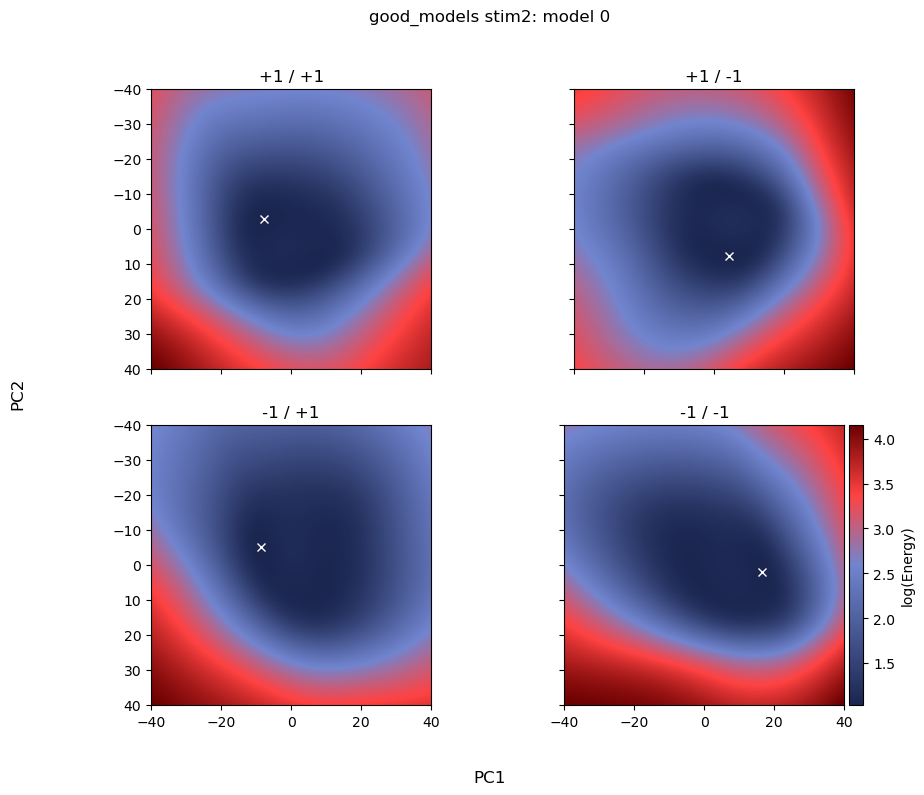

Loading synX


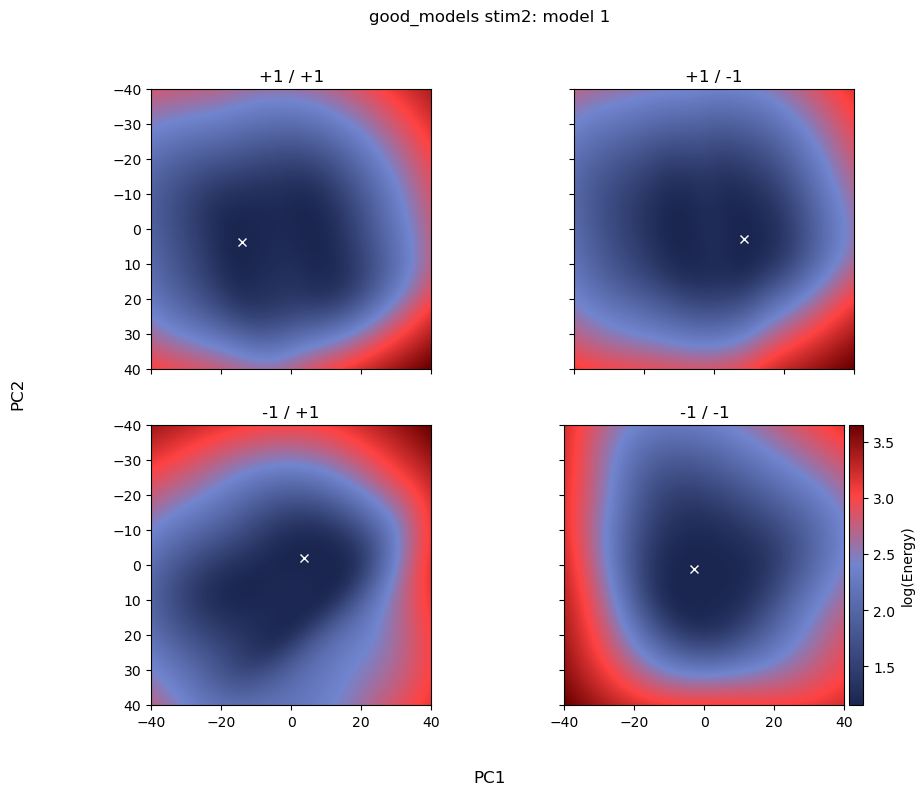

Loading synX


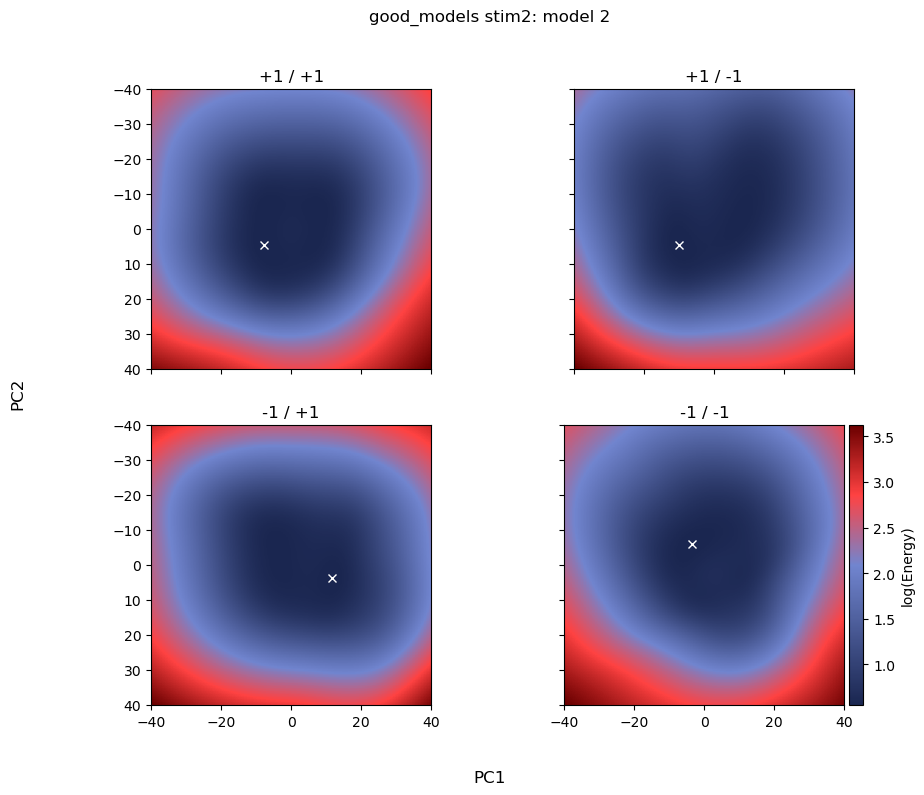

In [ ]:
# delay = 150 -- on separate plots
importlib.reload(tu)
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
                             suptitle=f'{models_type} stim2: model {i_model}',
                             xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    # tu.plot_energy_landscape_over_null(good_model_list[i_model], settings, 'stim2',
    #                          title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

Loading synX
Loading synX null


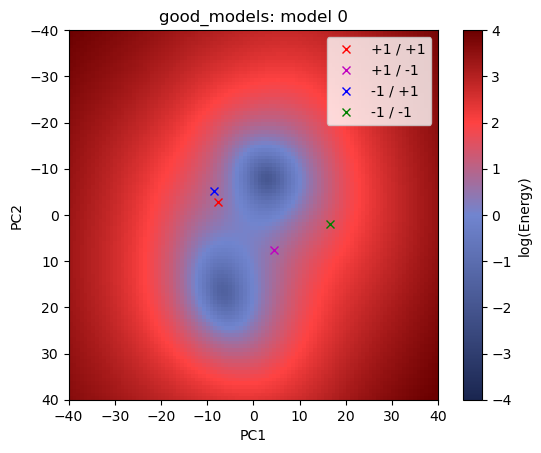

Loading synX
Loading synX null


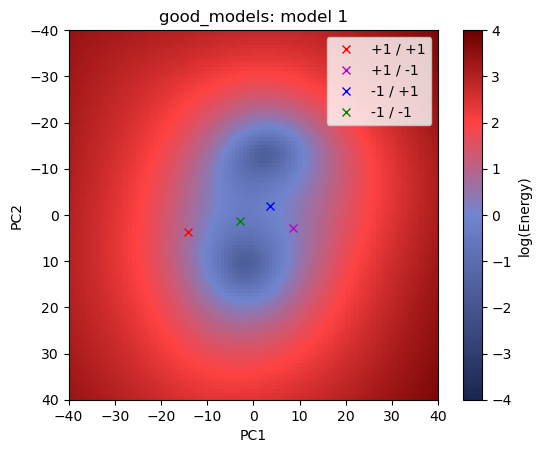

Loading synX
Loading synX null


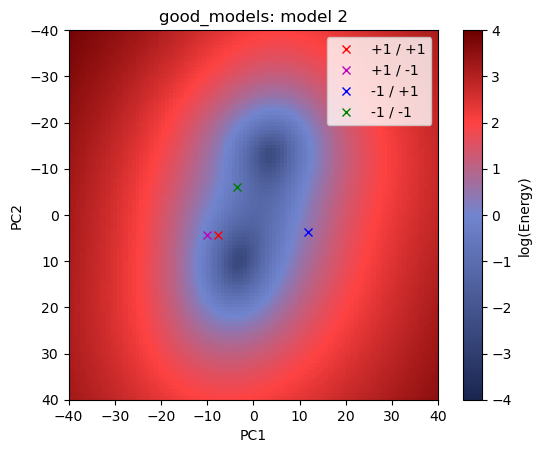

In [9]:
# delay = 150 -- on single combined plot (background is stim1=0, stim2=both)
importlib.reload(tu)
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    # tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
    #                          suptitle=f'{models_type} stim2: model {i_model}',
    #                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    tu.plot_energy_landscape_over_null_stim2(good_model_list[i_model], settings,
                                       xVec_lim=[-40,40], yVec_lim=[-40,40],
                                       title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

Loading synX
Loading synX null


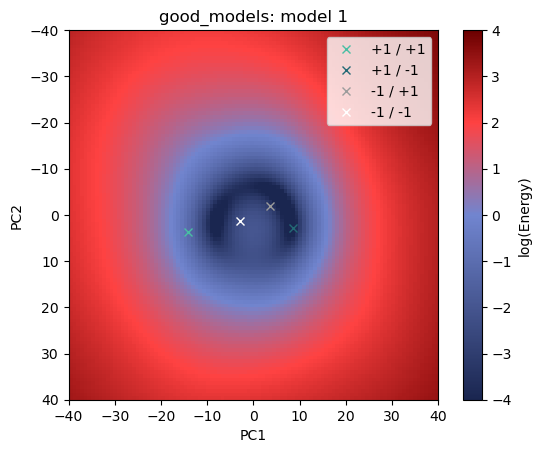

array([[-14.14141414,   3.63636364],
       [  8.48484848,   2.82828283],
       [  3.63636364,  -2.02020202],
       [ -2.82828283,   1.21212121]])

In [4]:
# delay = 150 -- on single null plot (background is stim1=0, stim2=0)
importlib.reload(tu)
i_model = 1
model_path = os.path.join(models_dir, good_model_list[i_model])
model = scipy.io.loadmat(model_path)
# print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
# perf = tu.get_perf(model_path = model_path, 
#                    settings=settings, n_trials=100, plot=0)

# tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
#                          suptitle=f'{models_type} stim2: model {i_model}',
#                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
tu.plot_energy_landscape_over_null_stim2(good_model_list[i_model], settings,
                                    xVec_lim=[-40,40], yVec_lim=[-40,40],
                                    title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    

Loading synX
Loading synX null
/home/nuttidalab/Documents/spikeRNN/results/2025_Cosyne/Poster/stim2_good_model_landscape.svg


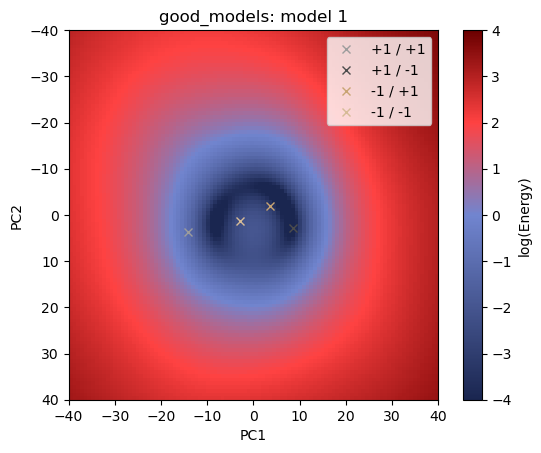

array([[-14.14141414,   3.63636364],
       [  8.48484848,   2.82828283],
       [  3.63636364,  -2.02020202],
       [ -2.82828283,   1.21212121]])

In [ ]:
# delay = 150 -- on single null plot (background is stim1=0, stim2=0)
importlib.reload(tu)
i_model = 1
model_path = os.path.join(models_dir, good_model_list[i_model])
model = scipy.io.loadmat(model_path)
# print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
# perf = tu.get_perf(model_path = model_path, 
#                    settings=settings, n_trials=100, plot=0)

# tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
#                          suptitle=f'{models_type} stim2: model {i_model}',
#                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
tu.plot_energy_landscape_over_null_stim2(good_model_list[i_model], settings,
                                    xVec_lim=[-40,40], yVec_lim=[-40,40],
                                    title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    

Loading synX
Loading synX null


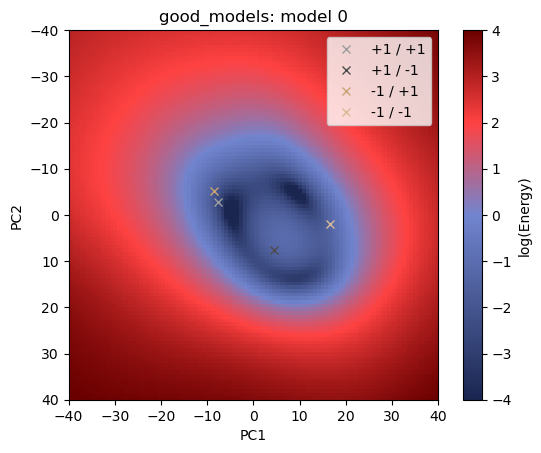

Loading synX
Loading synX null


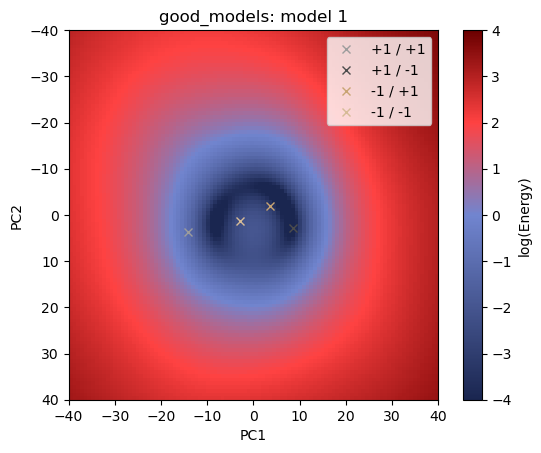

Loading synX
Loading synX null


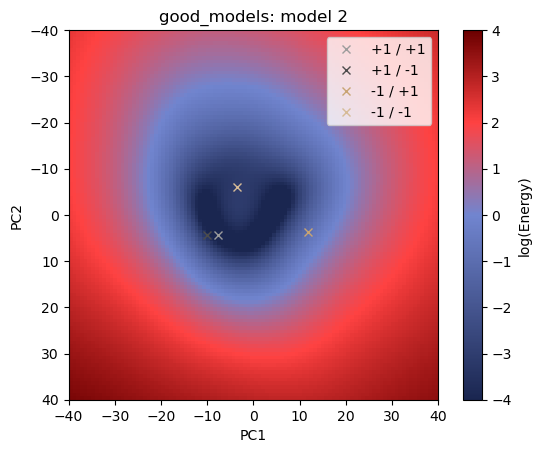

In [9]:
# delay = 150 -- on single null plot (background is stim1=0, stim2=0)
importlib.reload(tu)
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    # tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
    #                          suptitle=f'{models_type} stim2: model {i_model}',
    #                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    tu.plot_energy_landscape_over_null_stim2(good_model_list[i_model], settings,
                                       xVec_lim=[-40,40], yVec_lim=[-40,40],
                                       title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

## Bad model

In [9]:
models_type = 'bad_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
bad_model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [10]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

Loading synX


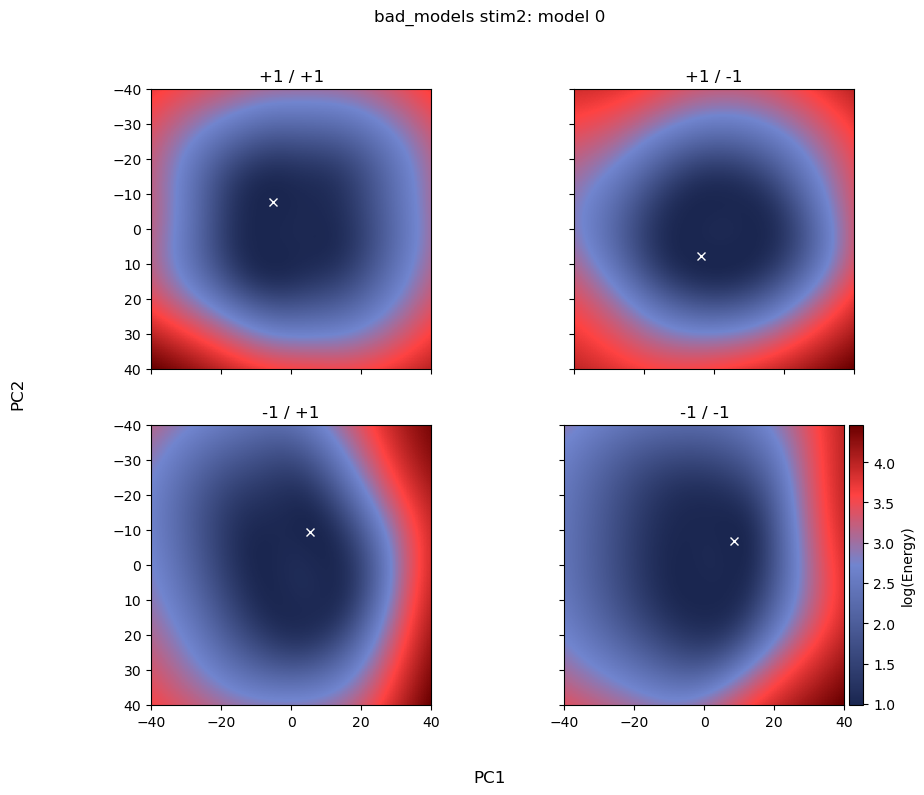

Loading synX


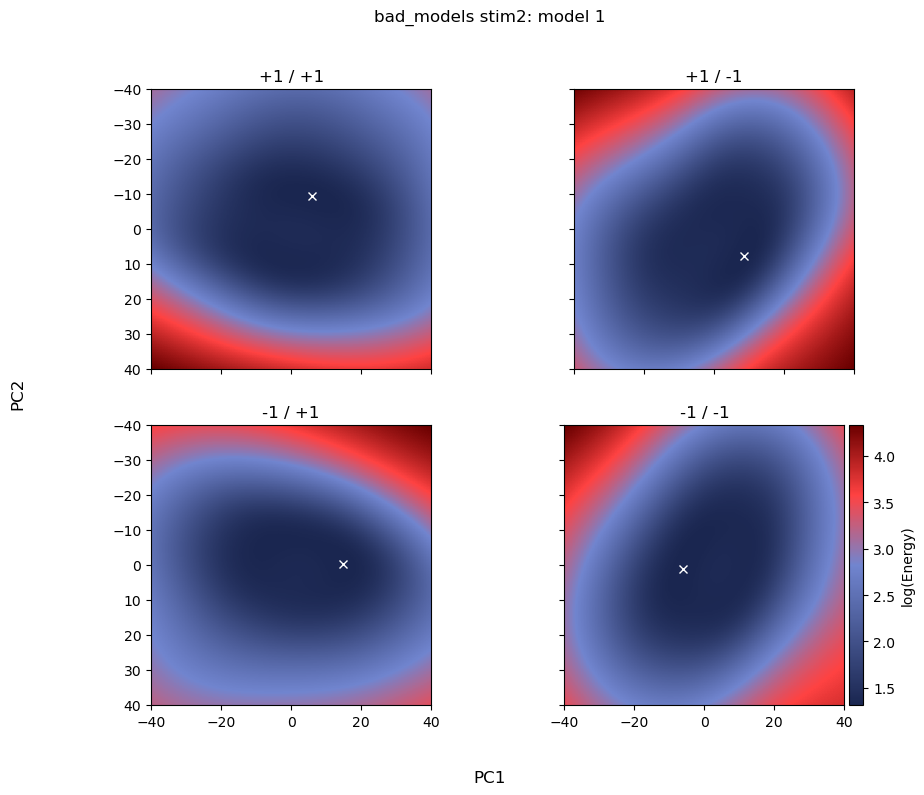

Loading synX


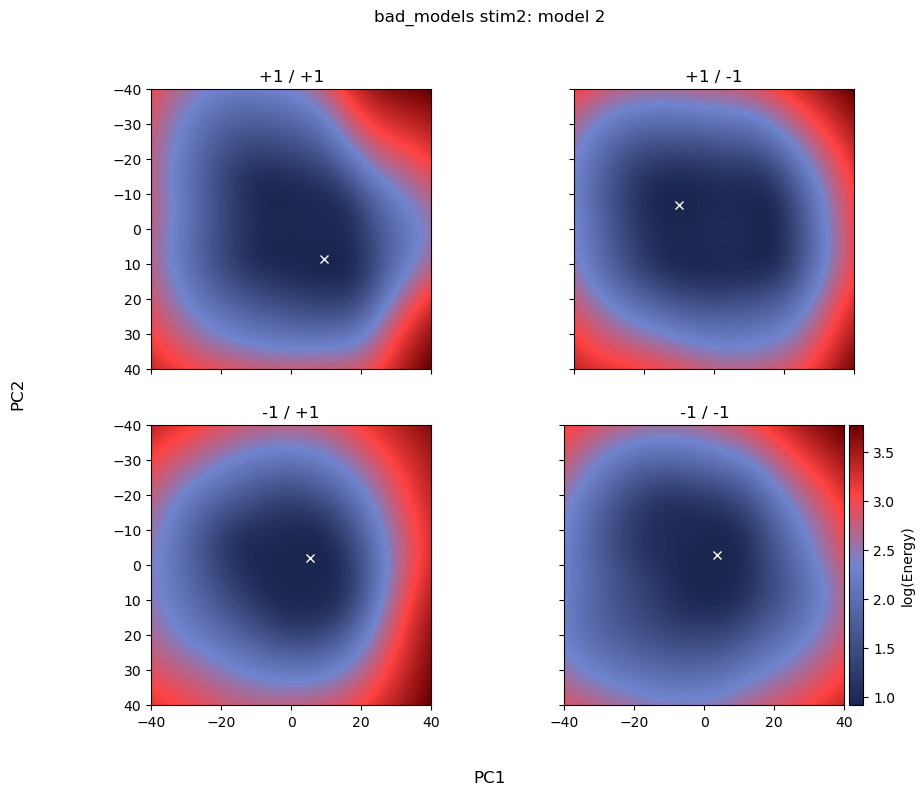

In [15]:
# delay = 150
importlib.reload(tu)
for i_model in range(len(bad_model_list)):
    model_path = os.path.join(models_dir, bad_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    tu.plot_energy_landscape_stim2(bad_model_list[i_model], settings,
                             suptitle=f'{models_type} stim2: model {i_model}',
                             xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    # tu.plot_energy_landscape_over_null(bad_model_list[i_model], settings, 'stim2',
    #                          title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

Loading synX
Loading synX null


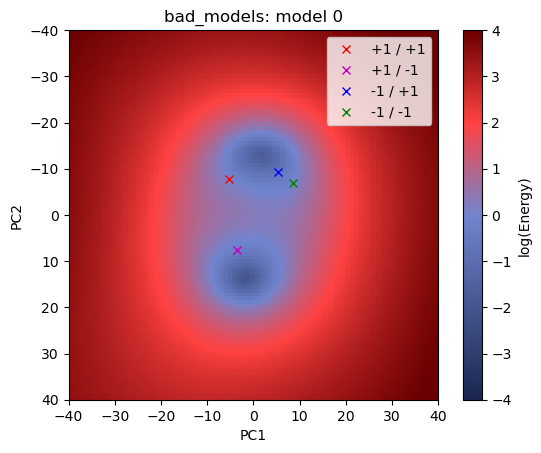

Loading synX
Loading synX null


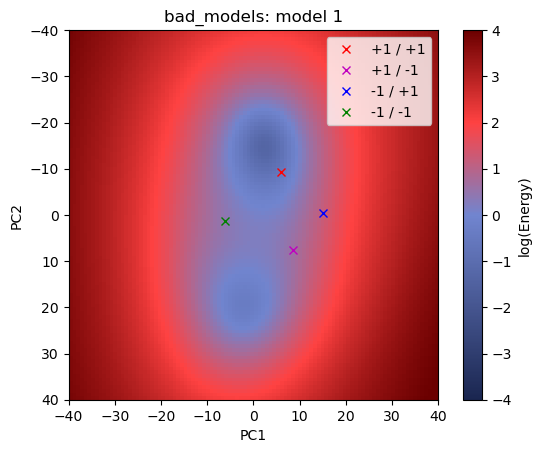

Loading synX
Loading synX null


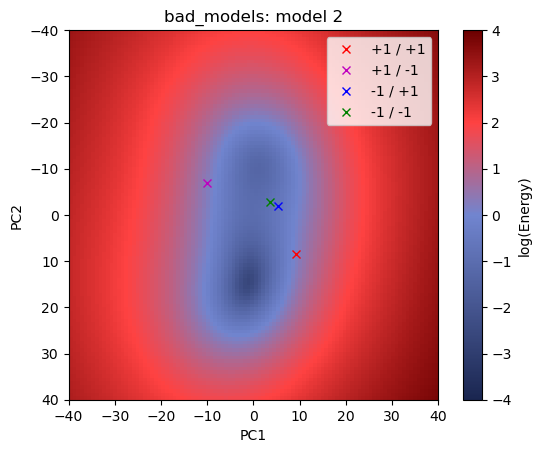

In [16]:
# delay = 150 -- on single combined plot (background is stim1=0, stim2=both)
importlib.reload(tu)
for i_model in range(len(bad_model_list)):
    model_path = os.path.join(models_dir, bad_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    # tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
    #                          suptitle=f'{models_type} stim2: model {i_model}',
    #                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    tu.plot_energy_landscape_over_null_stim2(bad_model_list[i_model], settings,
                                       xVec_lim=[-40,40], yVec_lim=[-40,40],
                                       title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

Loading synX
Loading synX null


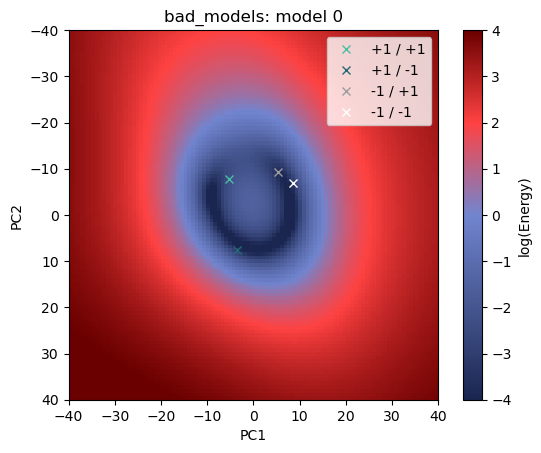

array([[-5.25252525, -7.67676768],
       [-3.63636364,  7.67676768],
       [ 5.25252525, -9.29292929],
       [ 8.48484848, -6.86868687]])

In [12]:
# delay = 150 -- on single null plot (background is stim1=0, stim2=0)
importlib.reload(tu)
i_model = 0
model_path = os.path.join(models_dir, bad_model_list[i_model])
model = scipy.io.loadmat(model_path)
# print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
# perf = tu.get_perf(model_path = model_path, 
#                    settings=settings, n_trials=100, plot=0)

# tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
#                          suptitle=f'{models_type} stim2: model {i_model}',
#                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
tu.plot_energy_landscape_over_null_stim2(bad_model_list[i_model], settings,
                                    xVec_lim=[-40,40], yVec_lim=[-40,40],
                                    title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')

Loading synX
Loading synX null
/home/nuttidalab/Documents/spikeRNN/results/2025_Cosyne/Poster/stim2_bad_model_landscape.svg


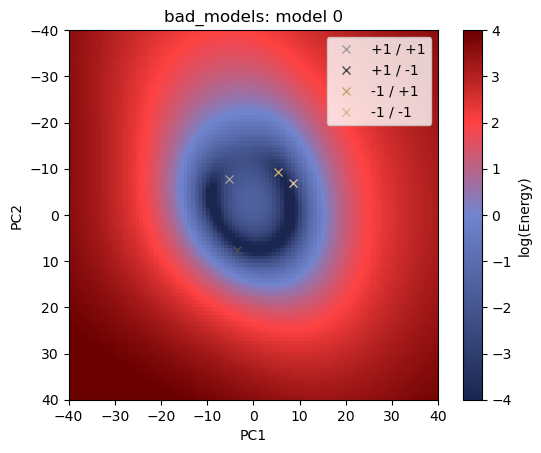

array([[-5.25252525, -7.67676768],
       [-3.63636364,  7.67676768],
       [ 5.25252525, -9.29292929],
       [ 8.48484848, -6.86868687]])

In [13]:
# delay = 150 -- on single null plot (background is stim1=0, stim2=0)
importlib.reload(tu)
i_model = 0
model_path = os.path.join(models_dir, bad_model_list[i_model])
model = scipy.io.loadmat(model_path)
# print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
# perf = tu.get_perf(model_path = model_path, 
#                    settings=settings, n_trials=100, plot=0)

# tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
#                          suptitle=f'{models_type} stim2: model {i_model}',
#                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
tu.plot_energy_landscape_over_null_stim2(bad_model_list[i_model], settings,
                                    xVec_lim=[-40,40], yVec_lim=[-40,40],
                                    title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')

Loading synX
Loading synX null


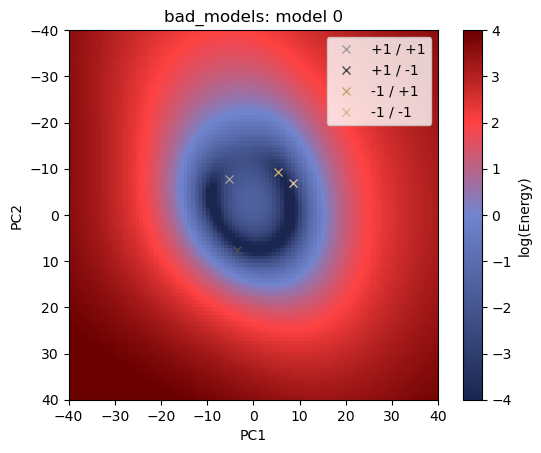

Loading synX
Loading synX null


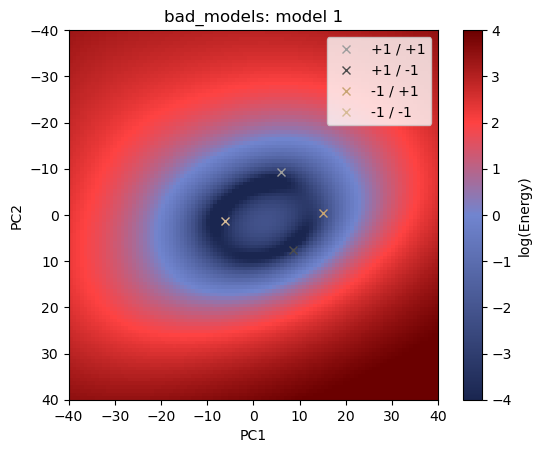

Loading synX
Loading synX null


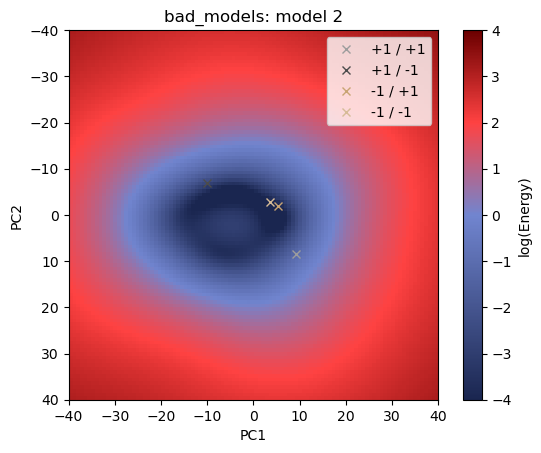

In [12]:
# delay = 150 -- on single null plot (background is stim1=0, stim2=0)
importlib.reload(tu)
for i_model in range(len(bad_model_list)):
    model_path = os.path.join(models_dir, bad_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    # tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
    #                          suptitle=f'{models_type} stim2: model {i_model}',
    #                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    tu.plot_energy_landscape_over_null_stim2(bad_model_list[i_model], settings,
                                       xVec_lim=[-40,40], yVec_lim=[-40,40],
                                       title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

## Lesion model

In [2]:
models_type = 'lesion_models'

if models_type == 'lesion_models':
        models_type = 'good_models'
        lesion = 'ii'
        lesion_flag = f'_lesion{lesion}'
else:
    lesion = ''
    lesion_flag = ''

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
good_model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

Loading synX


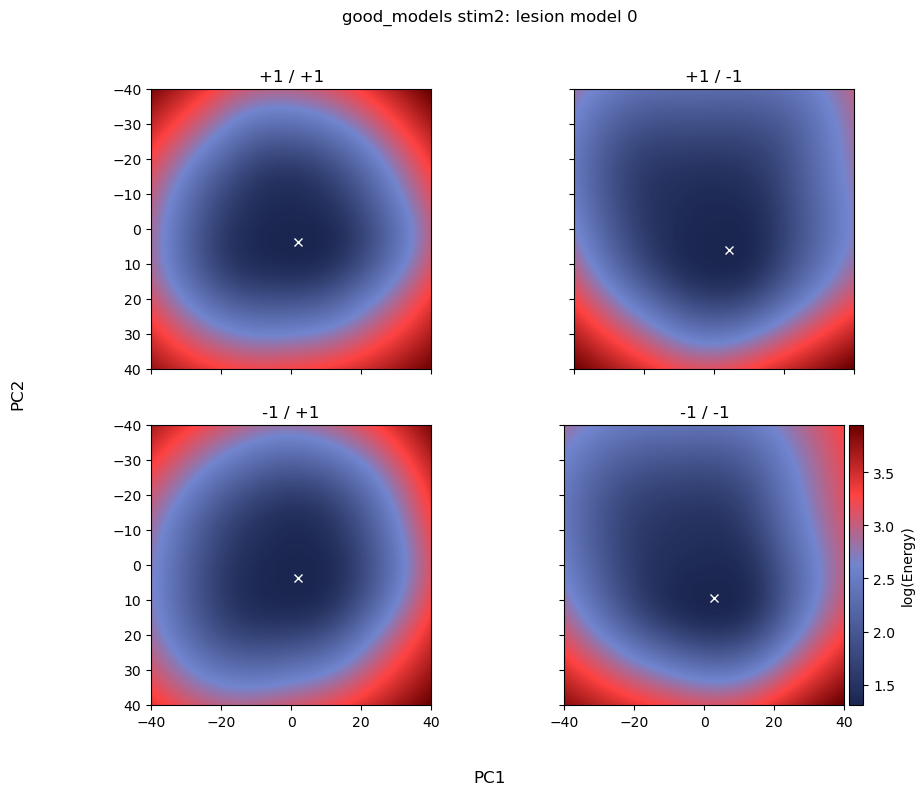

Loading synX


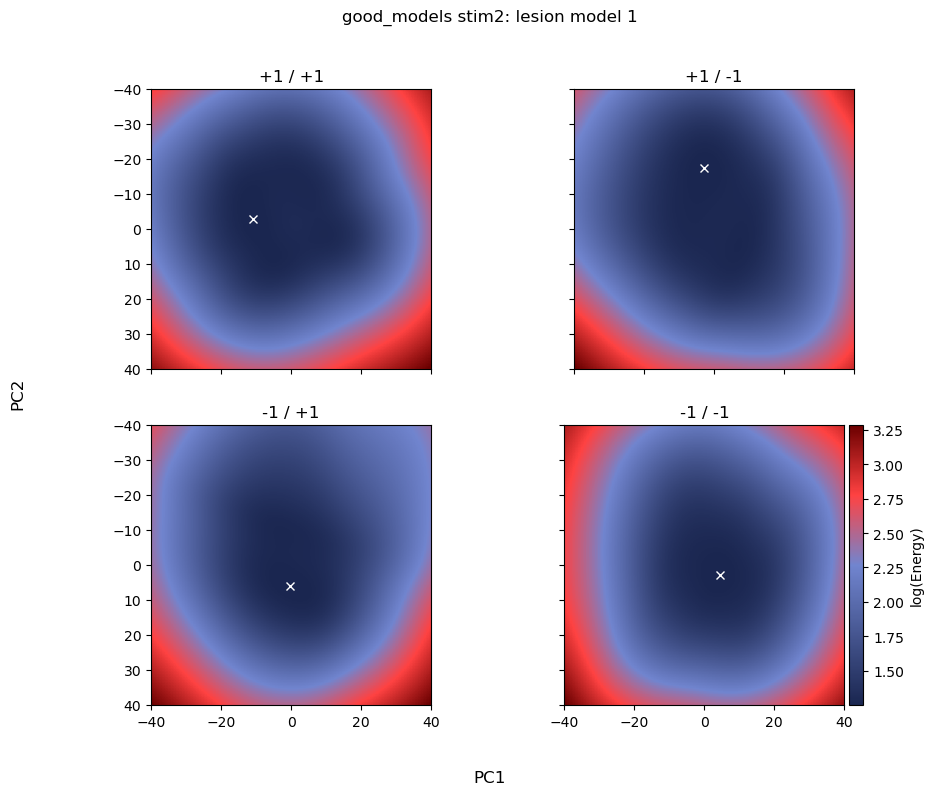

Loading synX


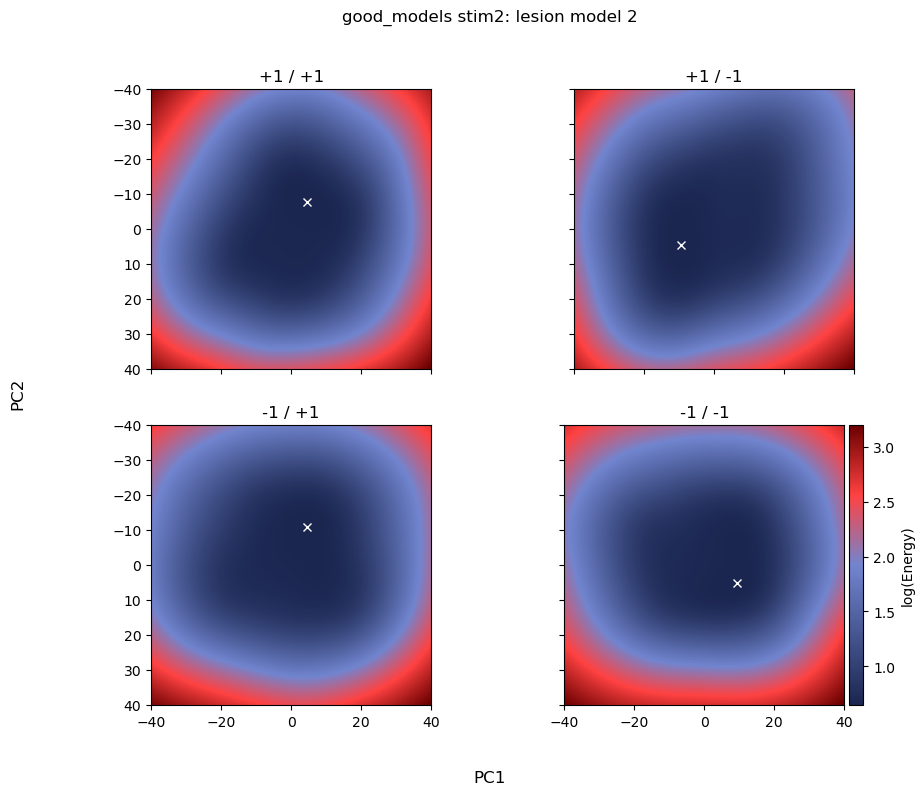

In [5]:
# delay = 150 -- on separate plots
importlib.reload(tu)
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    tu.plot_energy_landscape_stim2(good_model_list[i_model], settings, lesion='ii',
                             suptitle=f'{models_type} stim2: lesion model {i_model}',
                             xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    # tu.plot_energy_landscape_over_null(good_model_list[i_model], settings, 'stim2',
    #                          title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

Loading synX
Loading synX null


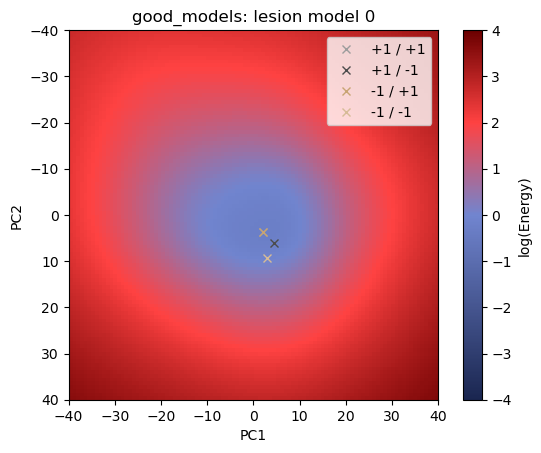

Loading synX
Loading synX null


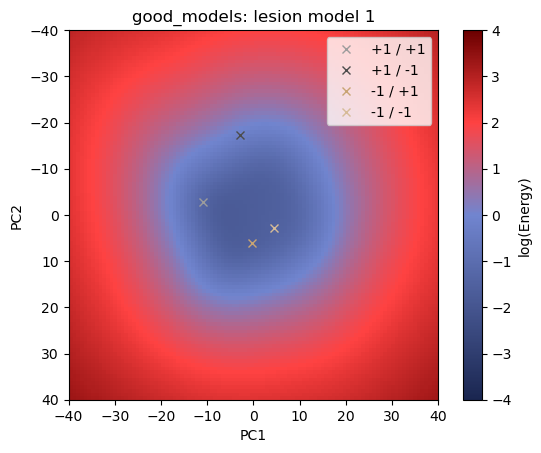

Loading synX
Loading synX null


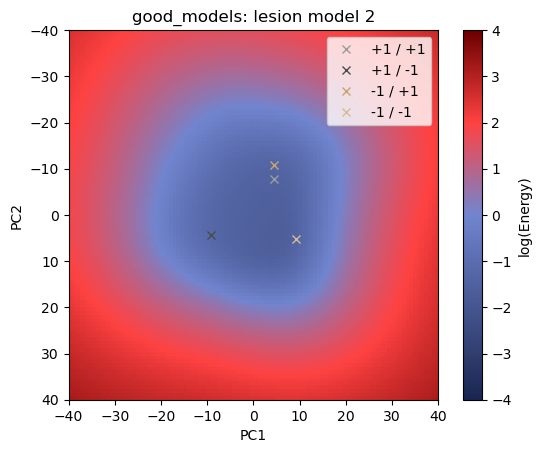

In [7]:
# delay = 150 -- on single combined plot (background is stim1=0, stim2=both)
importlib.reload(tu)
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    # tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
    #                          suptitle=f'{models_type} stim2: model {i_model}',
    #                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    tu.plot_energy_landscape_over_null_stim2(good_model_list[i_model], settings, lesion='ii',
                                       xVec_lim=[-40,40], yVec_lim=[-40,40],
                                       title=f'{models_type}: lesion model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

Loading synX
Loading synX null
/home/nuttidalab/Documents/spikeRNN/results/2025_Cosyne/Poster/stim2_good_model_landscape.svg


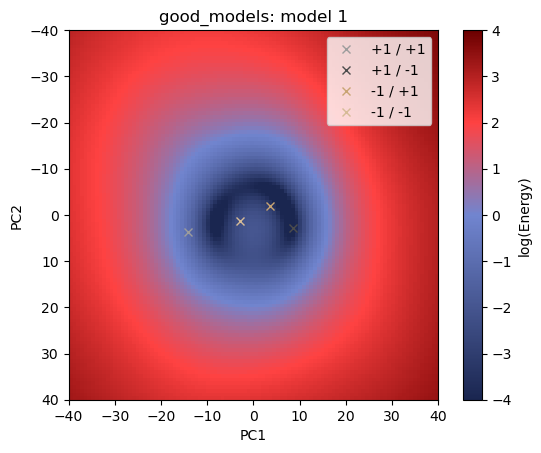

array([[-14.14141414,   3.63636364],
       [  8.48484848,   2.82828283],
       [  3.63636364,  -2.02020202],
       [ -2.82828283,   1.21212121]])

In [ ]:
# delay = 150 -- on single null plot (background is stim1=0, stim2=0)
importlib.reload(tu)
i_model = 1
model_path = os.path.join(models_dir, good_model_list[i_model])
model = scipy.io.loadmat(model_path)
# print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
# perf = tu.get_perf(model_path = model_path, 
#                    settings=settings, n_trials=100, plot=0)

# tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
#                          suptitle=f'{models_type} stim2: model {i_model}',
#                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
tu.plot_energy_landscape_over_null_stim2(good_model_list[i_model], settings,
                                    xVec_lim=[-40,40], yVec_lim=[-40,40],
                                    title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    

Loading synX
Loading synX null


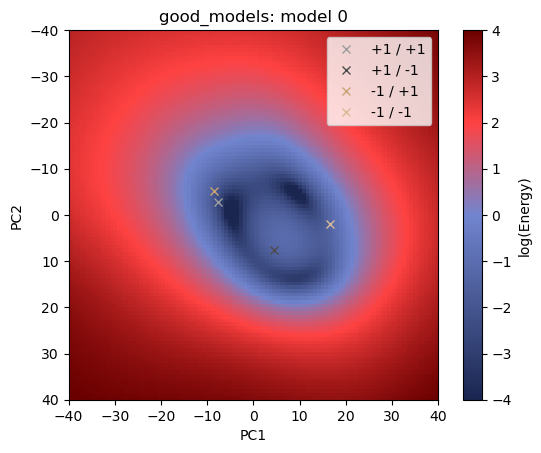

Loading synX
Loading synX null


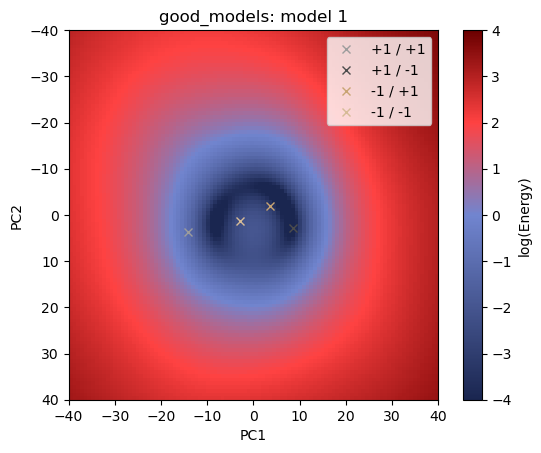

Loading synX
Loading synX null


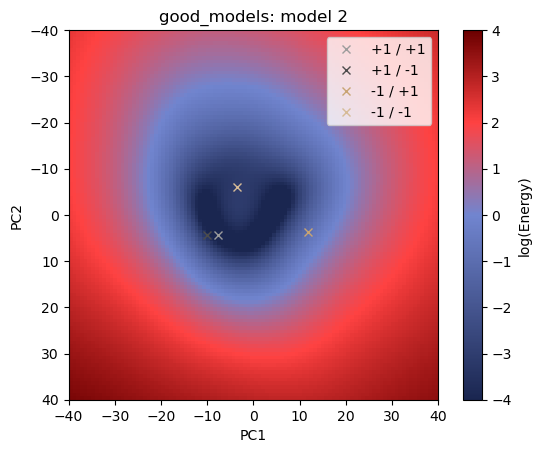

In [ ]:
# delay = 150 -- on single null plot (background is stim1=0, stim2=0)
importlib.reload(tu)
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    # tu.plot_energy_landscape_stim2(good_model_list[i_model], settings,
    #                          suptitle=f'{models_type} stim2: model {i_model}',
    #                          xVec_lim=[-40,40], yVec_lim=[-40,40])#, perf={perf:.2f}')
    tu.plot_energy_landscape_over_null_stim2(good_model_list[i_model], settings,
                                       xVec_lim=[-40,40], yVec_lim=[-40,40],
                                       title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

## Calculate distances for both

### ONLY RUN ONCE

In [9]:
importlib.reload(tu)

# models_types = ['good_models','bad_models']
models_types = ['lesion_models']
# models_types = ['bad_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

all_minima = []
for models_type in models_types:
    print(f'Analyzing {models_type}')

    if models_type == 'lesion_models':
        models_type = 'good_models'
        lesion = 'ii'
        lesion_flag = f'_lesion{lesion}'
    else:
        lesion = ''
        lesion_flag = ''
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    
    minima = np.zeros((len(model_list),4,2))
    for i_model in range(len(model_list)):
        model_path = os.path.join(models_dir, model_list[i_model])
        model = scipy.io.loadmat(model_path)
        these_minima = tu.plot_energy_landscape_over_null_stim2(model_list[i_model], settings, 
                                                                lesion=lesion, plot=0)
        if not isinstance(these_minima, type(None)):
            minima[i_model,:] = these_minima

    all_minima.append(minima)


Analyzing lesion_models
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX


In [11]:
# save all_dists
for i, models_type in enumerate(models_types):
    if models_type == 'lesion_models':
        models_type = 'good_models'
        lesion = 'ii'
        lesion_flag = f'_lesion{lesion}'
    else:
        lesion = ''
        lesion_flag = ''
    
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    these_minima = np.array(all_minima[i])
    print(these_minima.shape)
    np.save(f'{results_dir}ratemodel_delay{settings["delay"]}{lesion_flag}_stim2_minima.npy', these_minima)
    print(f'Saved {results_dir}ratemodel_delay{settings["delay"]}{lesion_flag}_stim2_minima.npy')


(41, 4, 2)
Saved /scratch/spikeRNN/models/DMS_OSF/good_models/ratemodel_delay150_lesionii_stim2_minima.npy


### now calc distances btwn pairs

In [12]:
# load all_perfs and all_dists
models_types = ['good_models','bad_models', 'lesion_models']
models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

all_perfs = []
all_minima = []
all_stim2_dists = []
all_delay_dists = []
for models_type in models_types:

    if models_type == 'lesion_models':
        models_type = 'good_models'
        lesion = 'ii'
        lesion_flag = f'_lesion{lesion}'
    else:
        lesion = ''
        lesion_flag = ''

    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
#     model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
#     model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
#     model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    these_perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}{lesion_flag}_perfs.npy')
    all_perfs.append(these_perfs)
    these_minima = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}{lesion_flag}_stim2_minima.npy')
    all_minima.append(these_minima)
    these_delay_dists = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}{lesion_flag}_dists.npy')
    all_delay_dists.append(these_delay_dists)

    # calc distances btwn all points for each minima row
    dists = np.zeros((these_minima.shape[0], 6))
    for i_model, mins in enumerate(these_minima):
        dists[i_model] = pdist(mins)
    all_stim2_dists.append(dists)


#### make some visualizations

In [ ]:
# squareform(all_stim2_dists[0][0])

array([[ 0.        , 15.69569889,  1.94886681, 24.37882502],
       [15.69569889,  0.        , 17.57285475, 13.11197099],
       [ 1.94886681, 17.57285475,  0.        , 25.7797983 ],
       [24.37882502, 13.11197099, 25.7797983 ,  0.        ]])

In [13]:
# get labels
stims = ['+1','-1']
labels = []
for i, stim1 in enumerate(stims):
    for j, stim2 in enumerate(stims):
        labels.append(f'{stim1}/{stim2}')

# get comparison labels
stim_comp_labels = []
for i, label in enumerate(labels):
    for j in range(i+1, len(labels)):
        stim_comp_labels.append(f'{label} to {labels[j]}')
print(stim_comp_labels)

['+1/+1 to +1/-1', '+1/+1 to -1/+1', '+1/+1 to -1/-1', '+1/-1 to -1/+1', '+1/-1 to -1/-1', '-1/+1 to -1/-1']


In [14]:
# i want to re-sort the row order

order_idx = [0, 5, 2, 3, 1, 4]
stim_comp_labels = [stim_comp_labels[i] for i in order_idx]
print(stim_comp_labels)
for i in range(len(all_stim2_dists)):
    all_stim2_dists[i] = all_stim2_dists[i][:,order_idx]

# first 2 are matching first stim
# next 2 are matching answer
# last 2 are matching second stim


['+1/+1 to +1/-1', '-1/+1 to -1/-1', '+1/+1 to -1/-1', '+1/-1 to -1/+1', '+1/+1 to -1/+1', '+1/-1 to -1/-1']


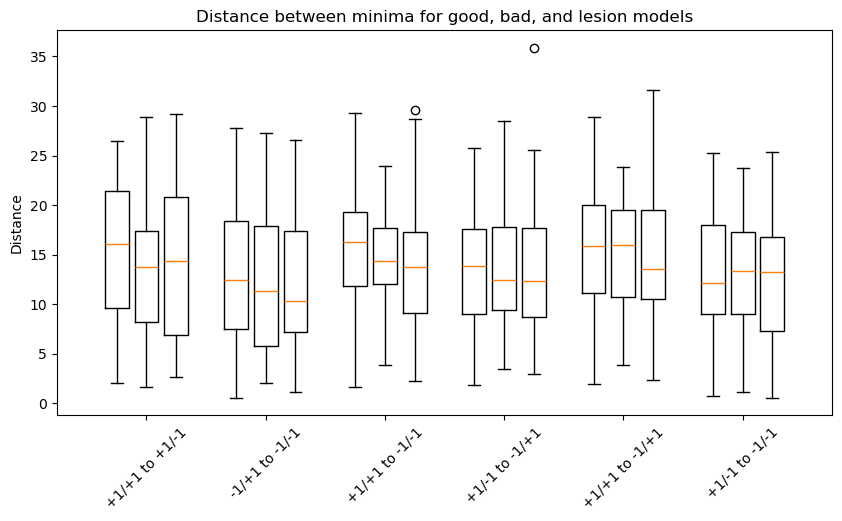

In [ ]:
# plot dists as paired boxplots
from scipy.stats import mannwhitneyu

line_sep = 0.25
y_max = 29.5

fig, ax = plt.subplots(1,1, figsize=(10,5))
for i in range(6):
    plt.boxplot([all_stim2_dists[0][:,i], all_stim2_dists[1][:,i], all_stim2_dists[2][:,i]], positions=[i-line_sep, i, i+line_sep], widths=.2)

    # for idxs in [[0,1],[0,2],[1,2]]:
    #     stat, p = mannwhitneyu(all_stim2_dists[idxs[0]][:,i], all_stim2_dists[idxs[1]][:,i])
    #     if p < 0.05:
    #         ax.plot([i-line_sep, i+line_sep], [y_max, y_max], color='k')
    #         ax.text(i, y_max, '*', horizontalalignment='center')
    #         break
    #     # else:
    #     #     ax.text(i, y_max, f'p = {p:.2f}, n.s.', horizontalalignment='center')
    
    # stat, p = mannwhitneyu(all_stim2_dists[0][:,i], all_stim2_dists[1][:,i])
    # print(f'Statistics={stat}, p={p}')

    # if p < 0.05:
    #     ax.plot([i-line_sep, i+line_sep], [y_max, y_max], color='k')
    #     ax.text(i, y_max, '*', horizontalalignment='center')
    # else:
    #     ax.text(i, y_max, f'p = {p:.2f}, n.s.', horizontalalignment='center')
plt.xticks(range(6), stim_comp_labels, rotation=45)
plt.ylabel('Distance')
plt.title('Distance between minima for good, bad, and lesion models')
plt.show()

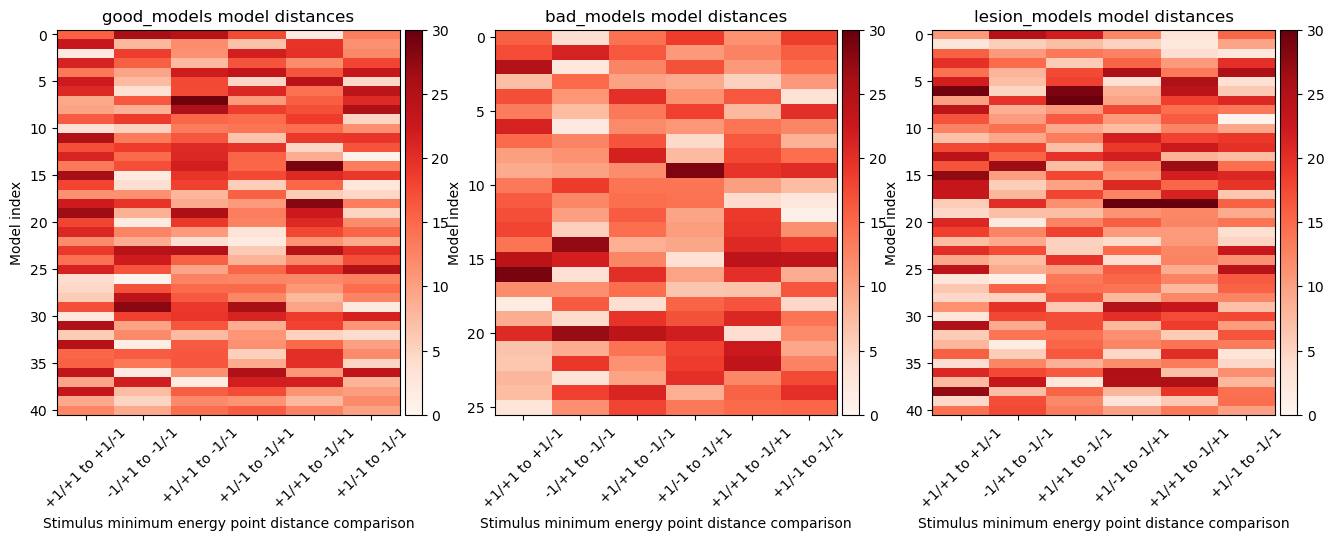

In [21]:
# plot distances btwn model points
fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(16,5))
for i in range(len(all_stim2_dists)):
    im = axs[i].imshow(all_stim2_dists[i], aspect='auto', cmap='Reds', vmin=0, vmax=30)
    axs[i].set_xticks(range(6))
    axs[i].set_xticklabels(stim_comp_labels, rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
plt.show()

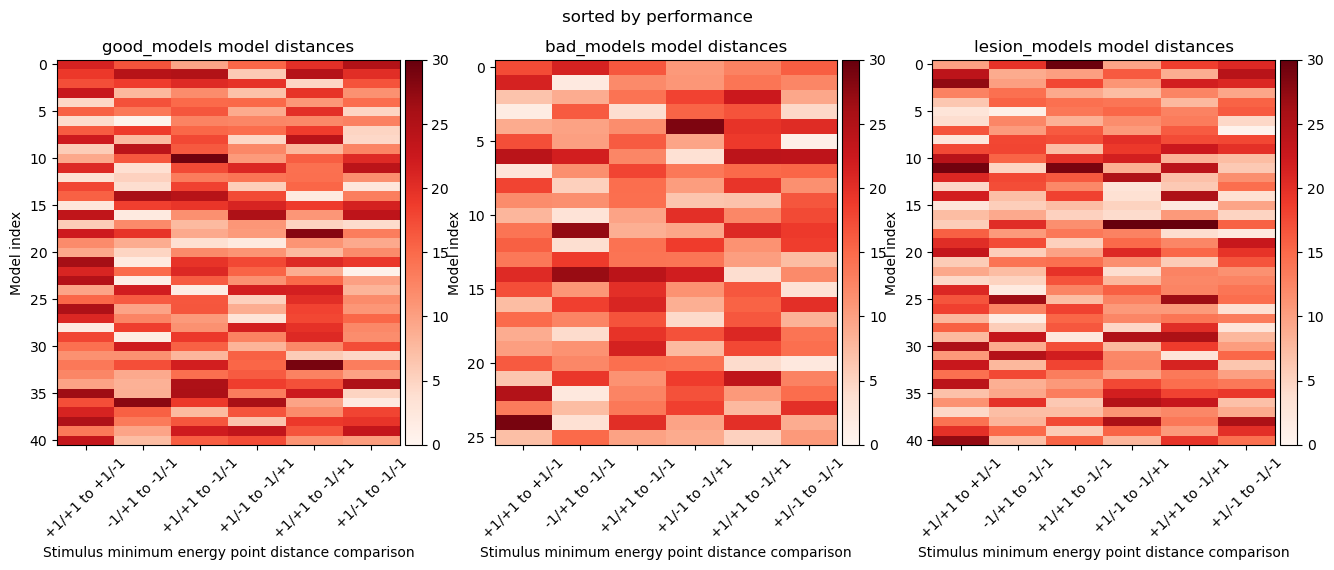

In [36]:
# sort rows of dists matrix by perf

# plot distances btwn model points
fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(16,5))
for i in range(len(all_stim2_dists)):
    sort_idx = np.argsort(all_perfs[i])
    im = axs[i].imshow(all_stim2_dists[i][sort_idx], aspect='auto', cmap='Reds', vmin=0, vmax=30)
    axs[i].set_xticks(range(6))
    axs[i].set_xticklabels(stim_comp_labels, rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
plt.suptitle('sorted by performance')
plt.show()

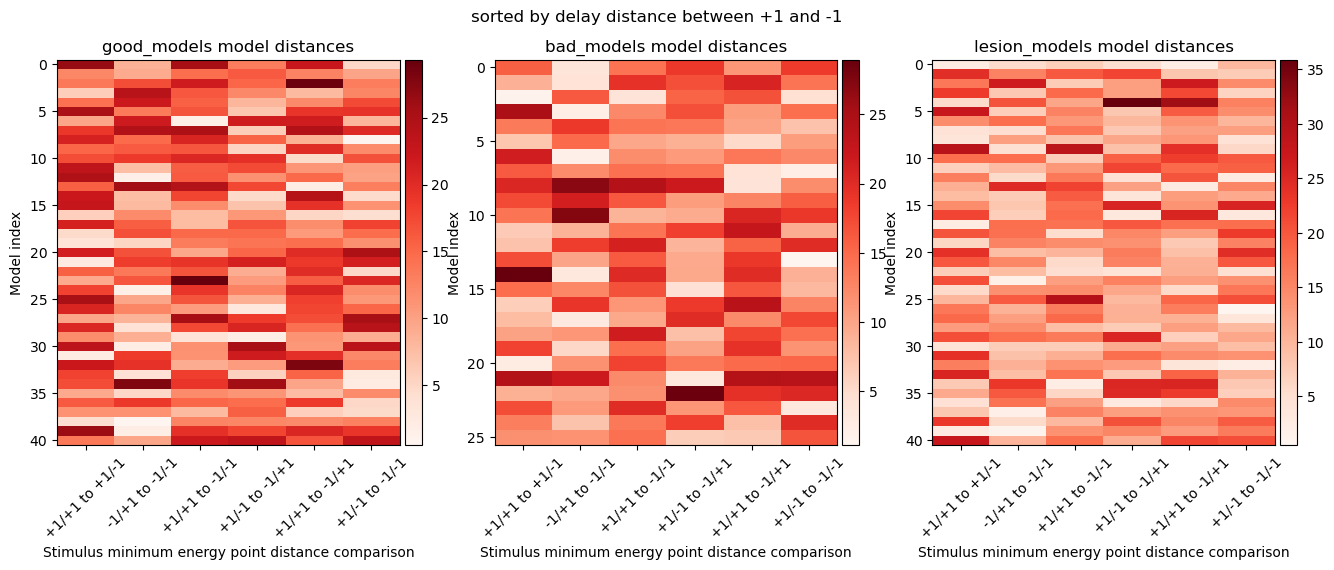

In [23]:
# sort rows of dists matrix by delay dist

# plot distances btwn model points
fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(16,5))
for i in range(len(all_stim2_dists)):
    sort_idx = np.argsort(all_delay_dists[i])
    im = axs[i].imshow(all_stim2_dists[i][sort_idx], aspect='auto', cmap='Reds')
    axs[i].set_xticks(range(6))
    axs[i].set_xticklabels(stim_comp_labels, rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
plt.suptitle('sorted by delay distance between +1 and -1')
plt.show()

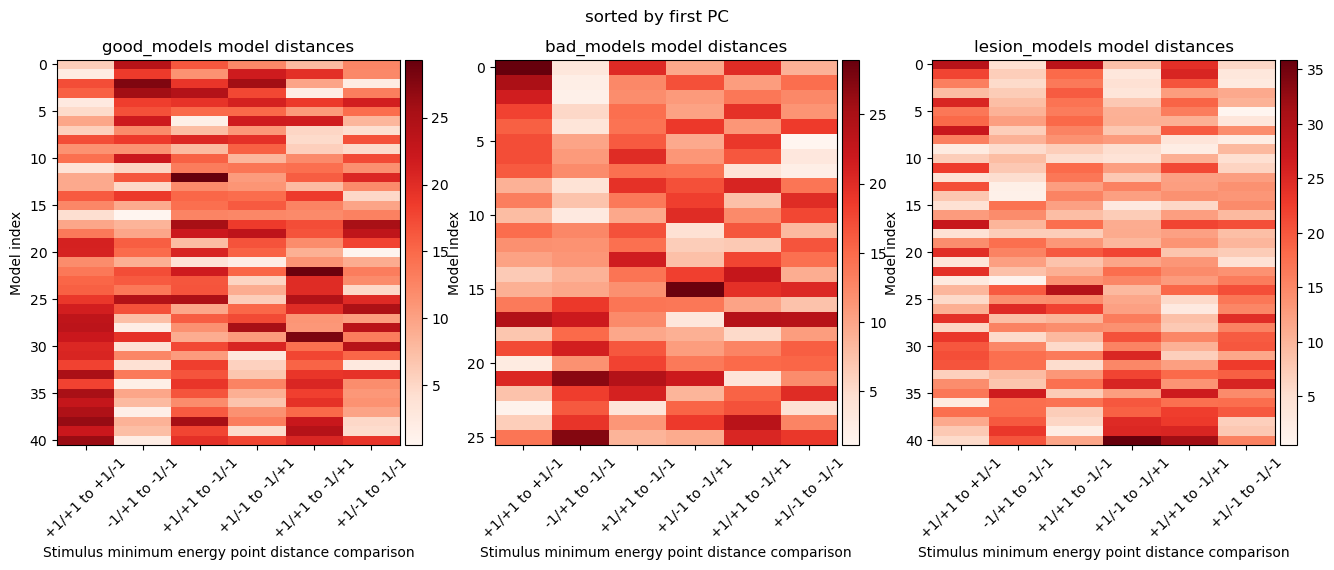

In [24]:
# sort rows of dist matrix by first PC

# plot distances btwn model points
fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(16,5))
for i in range(len(all_stim2_dists)):
    pca = PCA(n_components=5)
    pcs = pca.fit_transform(all_stim2_dists[i])
    sort_idx = np.argsort(pcs[:,0])
    im = axs[i].imshow(all_stim2_dists[i][sort_idx], aspect='auto', cmap='Reds')
    axs[i].set_xticks(range(6))
    axs[i].set_xticklabels(stim_comp_labels, rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
plt.suptitle('sorted by first PC')
plt.show()

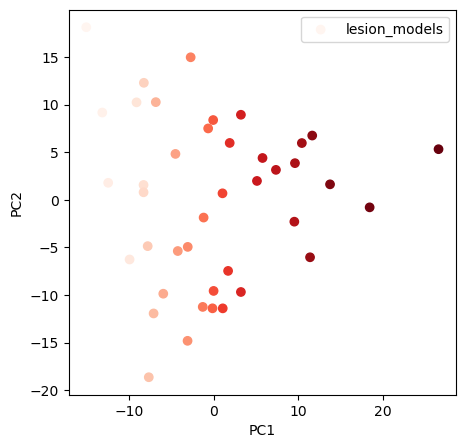

In [25]:
# plot 2d
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
i = 2; # look at lesion models

pca = PCA(n_components=2)
pcs = pca.fit_transform(all_stim2_dists[i])
sort_idx = np.argsort(pcs[:,0])
ax.scatter(pcs[:,0][sort_idx], pcs[:,1][sort_idx], label=models_types[i], 
            c=range(len(pcs)), cmap='Reds')


ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')
plt.legend()
plt.show()

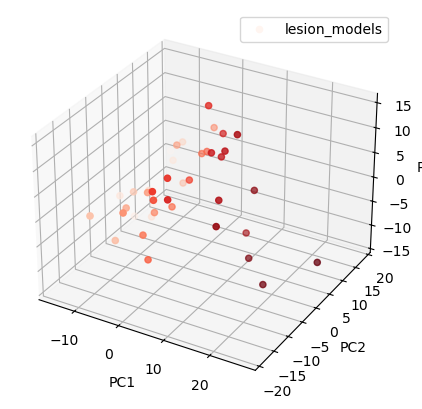

In [26]:
# plot 3d
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')
i = 2; # look at bad models

pca = PCA(n_components=3)
pcs = pca.fit_transform(all_stim2_dists[i])
sort_idx = np.argsort(pcs[:,0])
ax.scatter(pcs[:,0][sort_idx], pcs[:,1][sort_idx], pcs[:,2][sort_idx], 
           label=models_types[i], 
            c=range(len(pcs)), cmap='Reds')


ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.legend()
plt.show()

#### with zscore

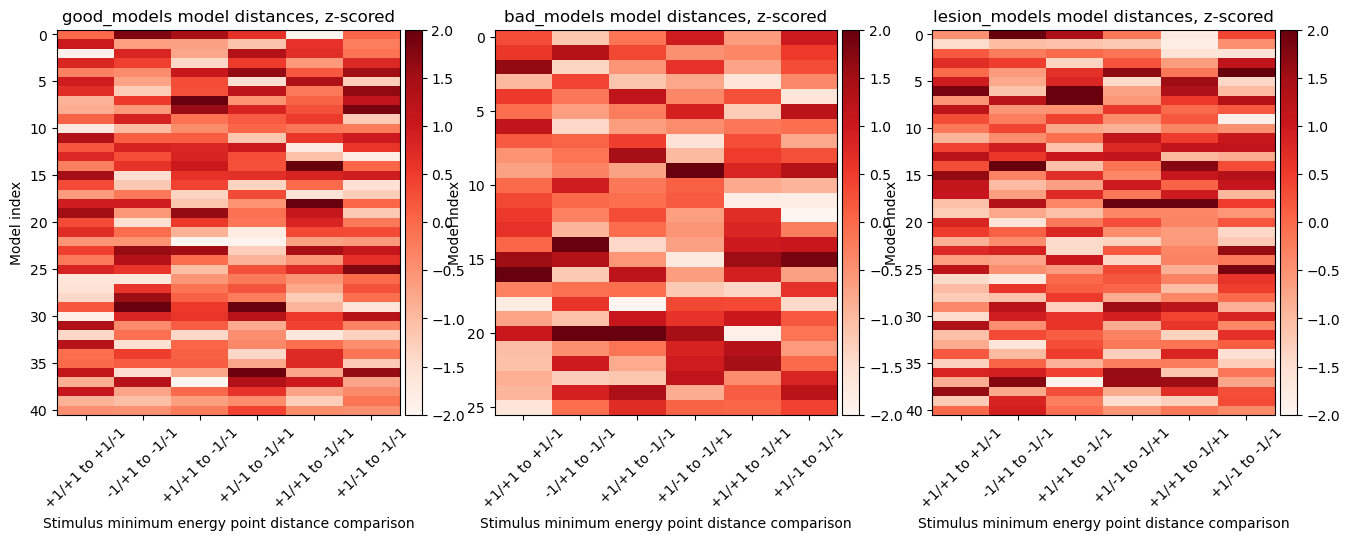

In [28]:
# plot distances btwn good model points
from scipy.stats import zscore

fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(16,5))
for i in range(len(all_stim2_dists)):
    im = axs[i].imshow(zscore(all_stim2_dists[i]), aspect='auto', cmap='Reds', vmax=2, vmin=-2)
    axs[i].set_xticks(range(6))
    axs[i].set_xticklabels(stim_comp_labels, rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances, z-scored')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
plt.show()

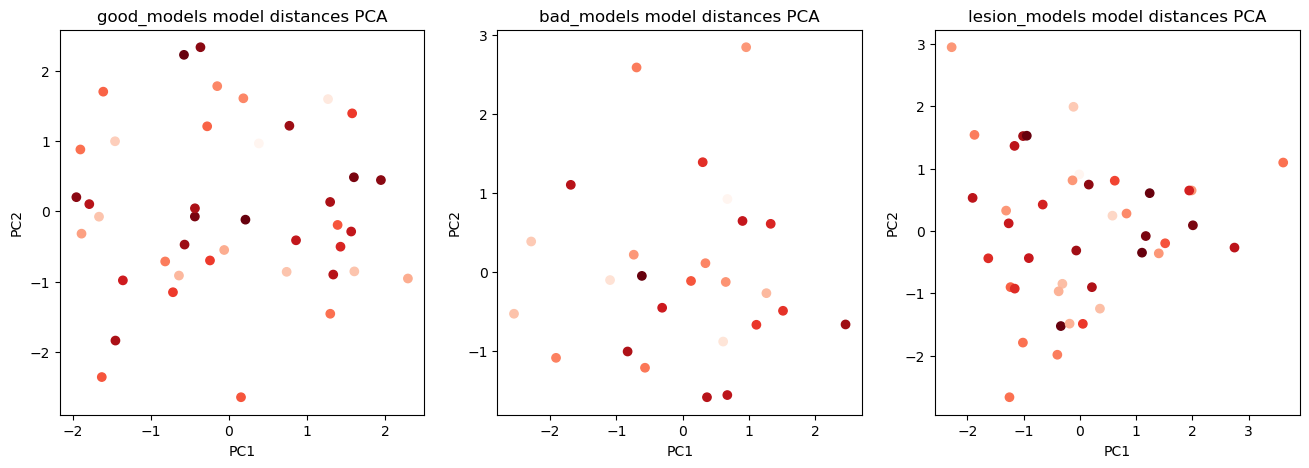

In [29]:
# PCA the distances for each set of models

fig, axs = plt.subplots(1,len(all_stim2_dists),figsize=(16,5))
all_pca = []
for i in range(len(all_stim2_dists)):
    pca = PCA(n_components=2)
    all_pca.append(pca.fit_transform(zscore(all_stim2_dists[i])))

    axs[i].scatter(all_pca[i][:,0], all_pca[i][:,1], c=all_perfs[i], cmap='Reds')
    axs[i].set_title(f'{models_types[i]} model distances PCA')
    axs[i].set_xlabel('PC1')
    axs[i].set_ylabel('PC2')
plt.show()

### add delay dists to the picture

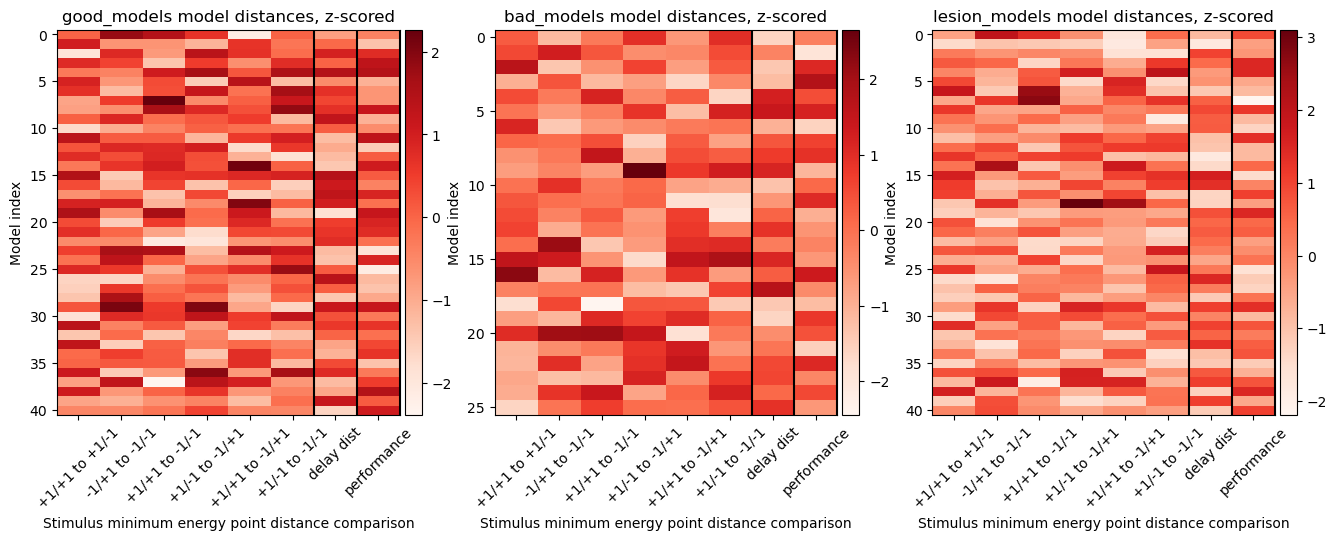

In [30]:
# plot distances btwn good model points
from scipy.stats import zscore

fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(16,5))
for i in range(len(all_stim2_dists)):
    dists = np.concatenate((all_stim2_dists[i], all_delay_dists[i][:,np.newaxis]), axis=1)
    dists_perf = np.concatenate((dists, all_perfs[i][:,np.newaxis]), axis=1)
    im = axs[i].imshow(zscore(dists_perf, axis=0), aspect='auto', cmap='Reds')
    axs[i].set_xticks(range(8))
    axs[i].set_xticklabels(stim_comp_labels+['delay dist']+['performance'], rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances, z-scored')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
    axs[i].axvline(6.5, color='k')
    axs[i].axvline(5.5, color='k')
    axs[i].axvline(7.5, color='k')

plt.show()

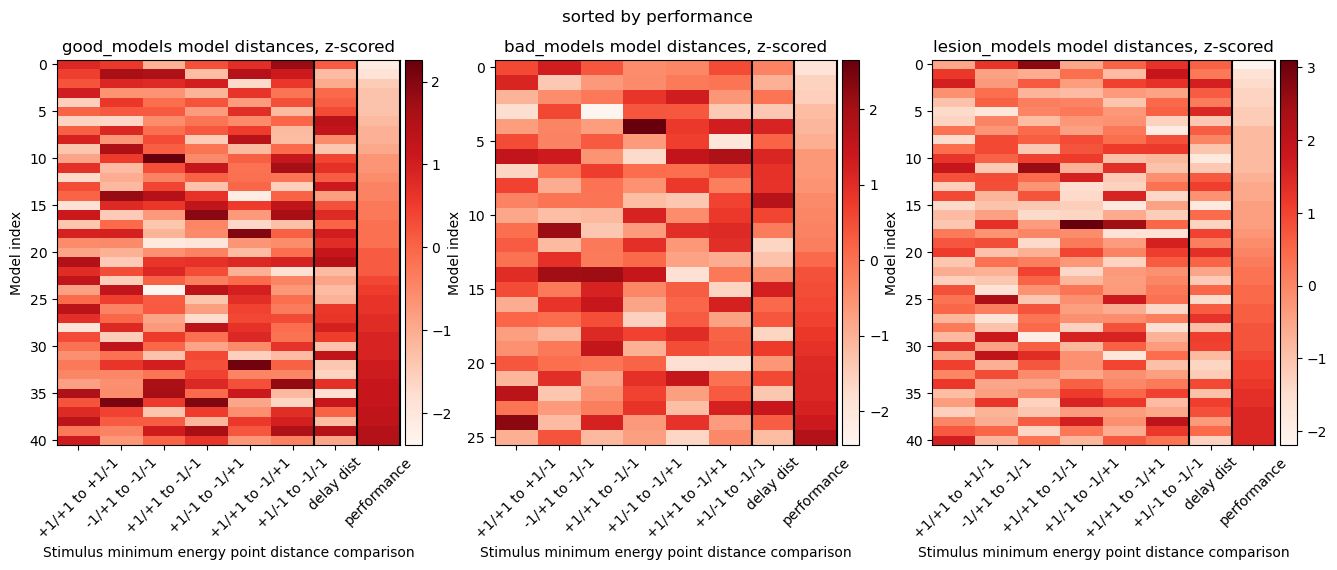

In [31]:
# sort rows of dists matrix by perf

# from scipy.stats import zscore

fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(16,5))
for i in range(len(all_stim2_dists)):
    sort_idx = np.argsort(all_perfs[i])
    dists = np.concatenate((all_stim2_dists[i], all_delay_dists[i][:,np.newaxis]), axis=1)
    dists_perf = np.concatenate((dists, all_perfs[i][:,np.newaxis]), axis=1)
    im = axs[i].imshow(zscore(dists_perf[sort_idx], axis=0), aspect='auto', cmap='Reds')
    axs[i].set_xticks(range(8))
    axs[i].set_xticklabels(stim_comp_labels+['delay dist']+['performance'], rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances, z-scored')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
    axs[i].axvline(6.5, color='k')
    axs[i].axvline(5.5, color='k')
    axs[i].axvline(7.5, color='k')
plt.suptitle('sorted by performance')
plt.show()

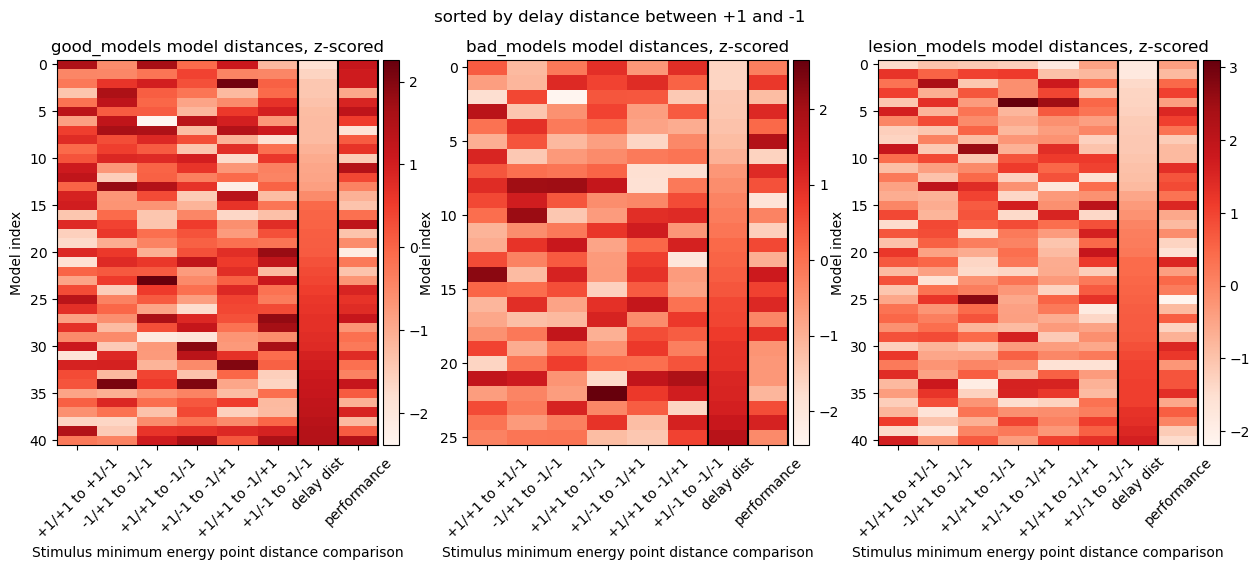

In [32]:
# sort rows of dists matrix by delay dist

# from scipy.stats import zscore

fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(15,5))
for i in range(len(all_stim2_dists)):
    sort_idx = np.argsort(all_delay_dists[i])
    dists = np.concatenate((all_stim2_dists[i], all_delay_dists[i][:,np.newaxis]), axis=1)
    dists_perf = np.concatenate((dists, all_perfs[i][:,np.newaxis]), axis=1)
    im = axs[i].imshow(zscore(dists_perf[sort_idx], axis=0), aspect='auto', cmap='Reds')
    axs[i].set_xticks(range(8))
    axs[i].set_xticklabels(stim_comp_labels+['delay dist']+['performance'], rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances, z-scored')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
    axs[i].axvline(6.5, color='k')
    axs[i].axvline(5.5, color='k')
    axs[i].axvline(7.5, color='k')
plt.suptitle('sorted by delay distance between +1 and -1')
plt.show()

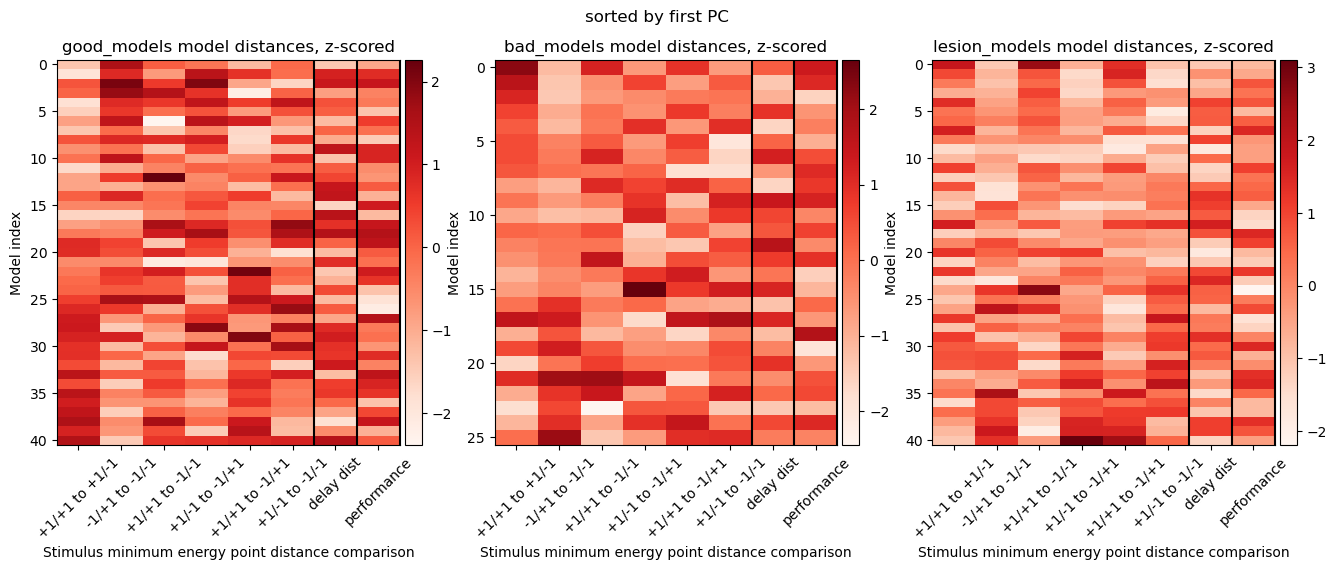

In [33]:
# sort rows of dist matrix by first PC

# from scipy.stats import zscore

fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(16,5))
for i in range(len(all_stim2_dists)):
    pca = PCA(n_components=5)
    pcs = pca.fit_transform(all_stim2_dists[i])
    sort_idx = np.argsort(pcs[:,0])
    dists = np.concatenate((all_stim2_dists[i], all_delay_dists[i][:,np.newaxis]), axis=1)
    dists_perf = np.concatenate((dists, all_perfs[i][:,np.newaxis]), axis=1)
    im = axs[i].imshow(zscore(dists_perf[sort_idx], axis=0), aspect='auto', cmap='Reds')
    axs[i].set_xticks(range(8))
    axs[i].set_xticklabels(stim_comp_labels+['delay dist']+['performance'], rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances, z-scored')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
    axs[i].axvline(6.5, color='k')
    axs[i].axvline(5.5, color='k')
    axs[i].axvline(7.5, color='k')
plt.suptitle('sorted by first PC')
plt.show()

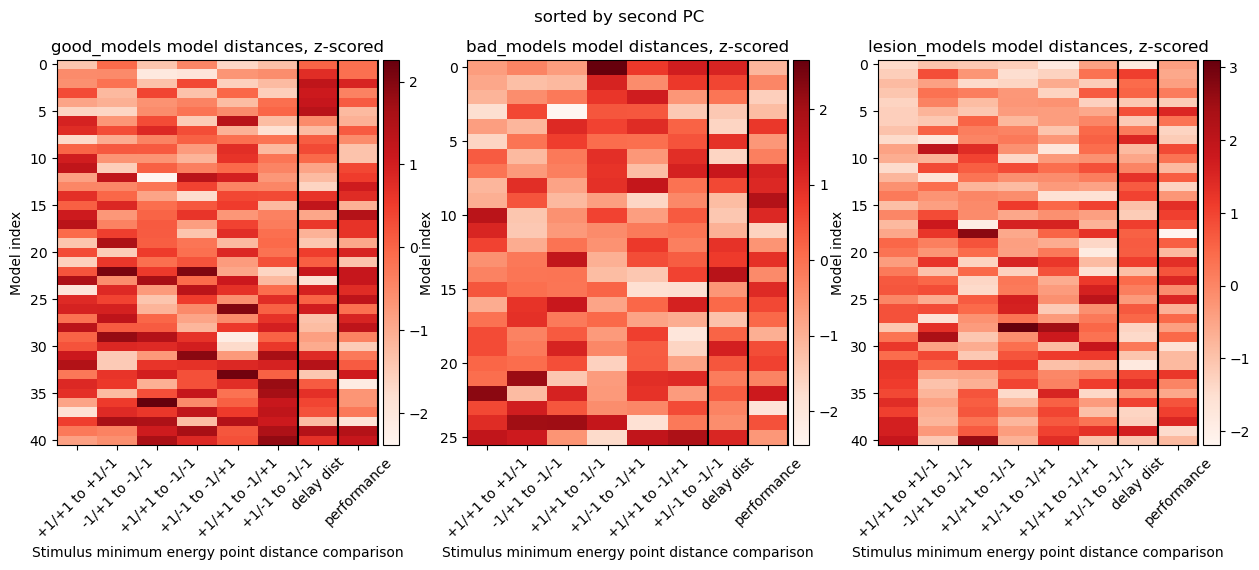

In [34]:
# sort rows of dist matrix by second PC

# from scipy.stats import zscore

fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(15,5))
for i in range(len(all_stim2_dists)):
    pca = PCA(n_components=5)
    pcs = pca.fit_transform(all_stim2_dists[i])
    sort_idx = np.argsort(pcs[:,1])
    dists = np.concatenate((all_stim2_dists[i], all_delay_dists[i][:,np.newaxis]), axis=1)
    dists_perf = np.concatenate((dists, all_perfs[i][:,np.newaxis]), axis=1)
    im = axs[i].imshow(zscore(dists_perf[sort_idx], axis=0), aspect='auto', cmap='Reds')
    axs[i].set_xticks(range(8))
    axs[i].set_xticklabels(stim_comp_labels+['delay dist']+['performance'], rotation=45)
    axs[i].set_title(f'{models_types[i]} model distances, z-scored')
    axs[i].set_ylabel('Model index')
    axs[i].set_xlabel('Stimulus minimum energy point distance comparison')
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
    axs[i].axvline(6.5, color='k')
    axs[i].axvline(5.5, color='k')
    axs[i].axvline(7.5, color='k')
plt.suptitle('sorted by second PC')
plt.show()

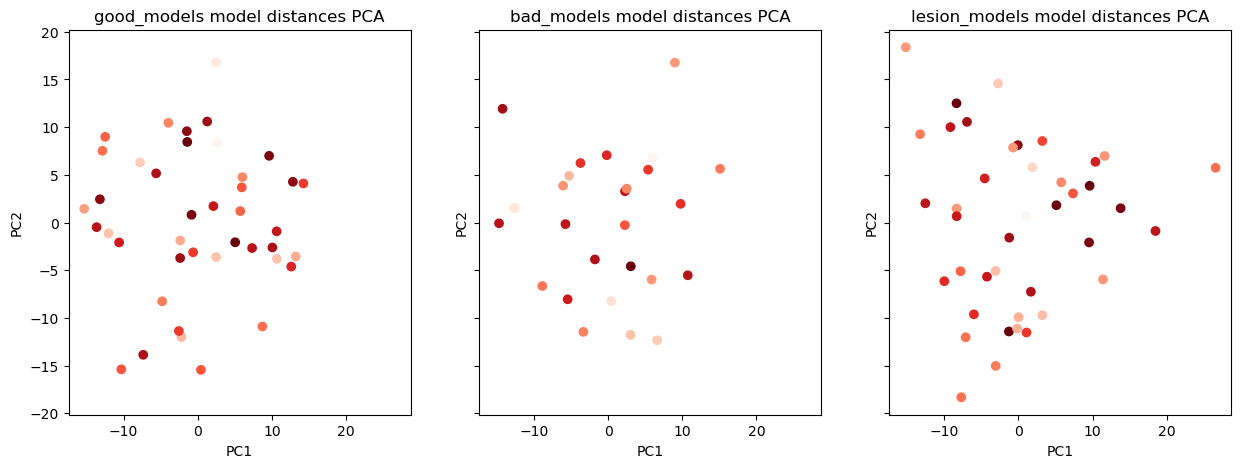

In [35]:
# make PCA plots including delay distances and performances


fig, axs = plt.subplots(1,len(all_stim2_dists), figsize=(15,5), sharex=True, sharey=True)
for i in range(len(all_stim2_dists)):
    dists = np.concatenate((all_stim2_dists[i], all_delay_dists[i][:,np.newaxis]), axis=1)
    dists_perf = np.concatenate((dists, all_perfs[i][:,np.newaxis]), axis=1)
    
    pca = PCA(n_components=5)
    pcs = pca.fit_transform(dists_perf)

    axs[i].scatter(pcs[:,0], pcs[:,1], c=all_perfs[i], cmap='Reds')
    axs[i].set_title(f'{models_types[i]} model distances PCA')
    axs[i].set_xlabel('PC1')
    axs[i].set_ylabel('PC2')
plt.show()
    